In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [20]:
df=pd.read_csv('train_titanic.csv')
df=df.drop(columns=['Name','Ticket','Cabin','PassengerId'])

In [21]:
df.sample(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
538,0,3,male,NaN,0,0,14.5000,S
764,0,3,male,16.0,0,0,7.7750,S
874,1,2,female,28.0,1,0,24.0000,C
219,0,2,male,30.0,0,0,10.5000,S
876,0,3,male,20.0,0,0,9.8458,S
184,1,3,female,4.0,0,2,22.0250,S
708,1,1,female,22.0,0,0,151.5500,S
542,0,3,female,11.0,4,2,31.2750,S
454,0,3,male,NaN,0,0,8.0500,S
59,0,3,male,11.0,5,2,46.9000,S


In [23]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df.sample(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
812,0,2,male,35.000000,0,0,10.5000,S
18,0,3,female,31.000000,1,0,18.0000,S
85,1,3,female,33.000000,3,0,15.8500,S
460,1,1,male,48.000000,0,0,26.5500,S
708,1,1,female,22.000000,0,0,151.5500,S
230,1,1,female,35.000000,1,0,83.4750,S
272,1,2,female,41.000000,0,1,19.5000,S
444,1,3,male,29.699118,0,0,8.1125,S
409,0,3,female,29.699118,3,1,25.4667,S
852,0,3,female,9.000000,1,1,15.2458,C


<Axes: ylabel='Density'>

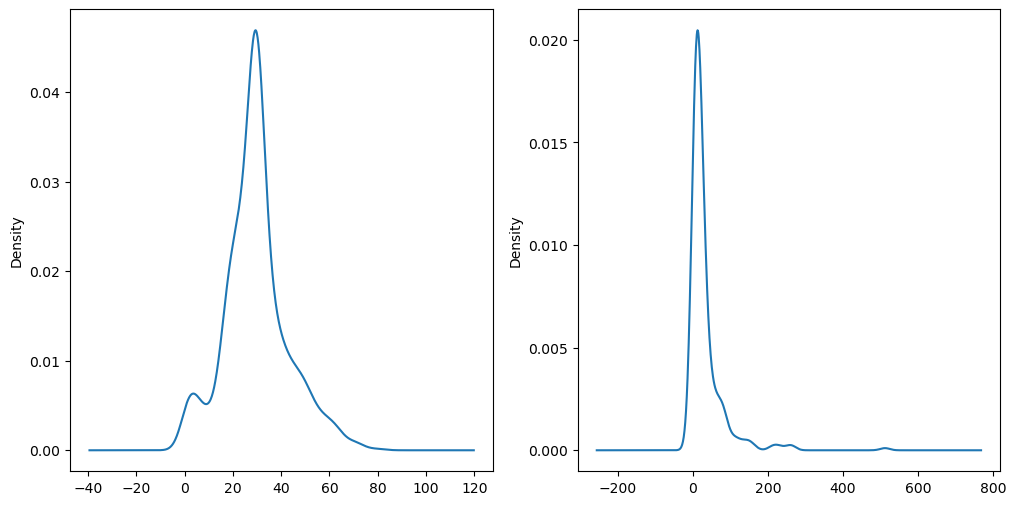

In [16]:
fig , ax=plt.subplots(1,2,figsize=(12,6))
df['Age'].plot(kind='kde',ax=ax[0])
df['Fare'].plot(kind='kde',ax=ax[1])

In [17]:
# distrbution of age is pretty normal however distbution of fare is not

In [24]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [26]:
num_cols=['Age','SibSp','Parch','Fare']
ord_cols=['Pclass']
cat_cols=['Sex','Embarked']

In [28]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [29]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer()),
    ('scaler',StandardScaler())
])

In [30]:
ord_pipeline=Pipeline([
    ('ordinal',OrdinalEncoder(categories=[[1,2,3]]))
])

In [31]:
cat_pipeline=Pipeline([
    ('onehot',OneHotEncoder(sparse_output=False,drop='first',dtype=int))
])

In [32]:
transformer=ColumnTransformer(
    transformers=[
        ('tnf1',num_pipeline,num_cols),
        ('tnf2',ord_pipeline,ord_cols),
        ('tnf3',cat_pipeline,cat_cols)
    ]
)

In [33]:
pipe=Pipeline([
    ('preprocessing',transformer),
    ('model',LogisticRegression())
])

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [35]:
pipe.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...), ('tnf2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
pred=pipe.predict(x_test)

In [37]:
acc=accuracy_score(y_test,pred)
acc

0.7723880597014925